### **Introdução às LSTMs (Long Short-Term Memory)**

As redes LSTM (Long Short-Term Memory) são um tipo especial de RNN projetada para **lidar com o problema de dependências de longo prazo** em sequências de dados. Elas **são amplamente utilizadas em tarefas de processamento de linguagem natural, reconhecimento de fala, e outras aplicações que envolvem sequências**.

#### **Por que LSTMs?**

Em RNNs tradicionais, o problema de desvanecimento de gradientes pode dificultar o aprendizado de dependências de longo prazo. As LSTMs resolvem esse problema através de uma arquitetura de memória mais complexa, que inclui células de memória capazes de preservar informações ao longo de várias etapas de tempo.

#### **Arquitetura de uma LSTM**

As LSTMs introduzem três "portas" (gates) principais para controlar o fluxo de informações:
- **Porta de Entrada (Input Gate)**: Controla quanta informação da entrada atual deve ser armazenada na célula de memória.
- **Porta de Esquecimento (Forget Gate)**: Decide quanta informação da célula de memória anterior deve ser mantida.
- **Porta de Saída (Output Gate)**: Controla quanta informação da célula de memória deve ser utilizada para produzir a saída atual.

Matematicamente, a atualização de uma célula LSTM pode ser descrita pelas seguintes equações:

$$
f_t = \sigma(W_f \cdot [h_{t-1}, x_t] + b_f)
$$
$$
i_t = \sigma(W_i \cdot [h_{t-1}, x_t] + b_i)
$$
$$
\tilde{C}_t = \tanh(W_C \cdot [h_{t-1}, x_t] + b_C)
$$
$$
C_t = f_t \cdot C_{t-1} + i_t \cdot \tilde{C}_t
$$
$$
o_t = \sigma(W_o \cdot [h_{t-1}, x_t] + b_o)
$$
$$
h_t = o_t \cdot \tanh(C_t)
$$

Onde:
- $f_t$, $i_t$, $o_t$ são as portas de esquecimento, entrada e saída, respectivamente.
- $C_t$ é o estado da célula.
- $h_t$ é o estado oculto.


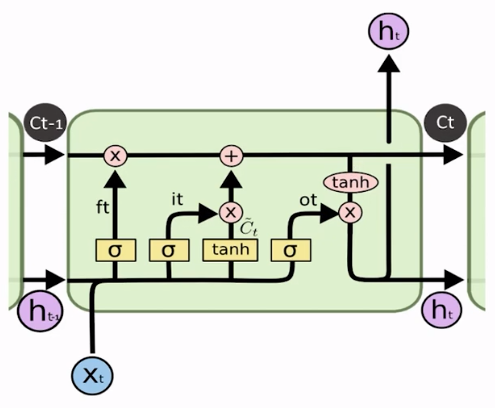

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import numpy as np
import matplotlib.pyplot as plt

### **Primeiros Passos com LSTM - Entradas Aleatórias**

Vamos começar criando uma LSTM simples e alimentá-la com entradas aleatórias. Isso nos ajudará a entender como a LSTM processa os dados e o formato das saídas.

#### **Explicação do Código**

- **`nn.LSTM`**: Implementa uma LSTM básica com uma ou mais camadas.
- **Parâmetros principais**:
  - `input_size`: Dimensão das entradas em cada passo de tempo.
  - `hidden_size`: Número de unidades na célula LSTM.
  - `num_layers`: Número de camadas empilhadas de LSTM.
  - `batch_first=True`: Faz com que o batch seja a primeira dimensão no tensor de entrada.

In [2]:
# Configurações
input_size = 5  # Tamanho da entrada em cada passo de tempo
hidden_size = 10  # Número de unidades na camada oculta
num_layers = 2  # Número de camadas empilhadas

# Criando uma LSTM
lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True) # Então a forma da entrada esperada é: (batch_size, seq_len, input_size).

In [9]:
# Criando uma entrada aleatória: (batch_size, seq_len, input_size)
batch_size = 8 # quantidade de seqûencias
seq_len = 7 # Quantidade de passos no tempo
x = torch.randn(batch_size, seq_len, input_size)
print(x)

# Executando a LSTM
output, (hn, cn) = lstm(x)

tensor([[[ 1.6424e+00,  6.9177e-01, -8.0174e-01,  1.1808e+00, -2.9618e-01],
         [ 5.8665e-01,  1.2272e-01, -2.0149e+00, -1.9860e+00, -1.5066e+00],
         [-2.4428e+00,  7.7582e-01, -4.1589e-01,  1.0268e+00, -3.1213e-01],
         [ 5.8501e-01,  7.0314e-01,  2.1419e+00,  4.8279e-01,  7.8738e-02],
         [-2.0689e-01,  2.0911e-01,  4.4945e-01, -6.4711e-02,  1.4437e-01],
         [-9.9903e-01,  5.8328e-01,  7.4079e-01, -4.3523e-02, -5.6722e-01],
         [-1.3266e+00,  6.4549e-01, -8.2817e-01,  1.3780e+00,  1.2565e+00]],

        [[-1.7387e+00, -1.5749e-01, -1.4712e+00,  4.2637e-01, -4.8604e-01],
         [ 5.0533e-01, -3.9663e-01, -1.2734e+00,  1.7135e-01,  1.2481e+00],
         [ 3.2628e-01, -5.1349e-01,  1.0668e+00,  1.6073e+00,  1.3842e+00],
         [ 1.5605e+00,  4.0516e-01,  6.9318e-01, -1.3062e-02, -1.6410e-01],
         [-8.8502e-01, -7.5545e-01,  8.8774e-01,  1.3800e+00, -1.7637e+00],
         [-4.9518e-01, -1.8426e+00, -3.0217e-02, -2.9485e-01, -1.5129e+00],
         [

### **Interpretação das Saídas da LSTM**

Vamos analisar o que as diferentes saídas da LSTM significam:

- **`output`**: Contém a saída de cada passo de tempo para cada sequência no batch. A forma será `(batch_size, seq_len, hidden_size)`.
- **`hn`**: O estado oculto final para cada camada e cada sequência no batch. A forma será `(num_layers, batch_size, hidden_size)`.
- **`cn`**: O estado da célula final para cada camada e cada sequência no batch. A forma será a mesma que `hn`.

In [ ]:
# Analisando as saídas
print("Shape da saída: ", output.shape)
print("Shape do estado oculto hn: ", hn.shape)
print("Shape do estado da célula cn: ", cn.shape)

Shape da saída:  torch.Size([8, 7, 10])
Shape do estado oculto hn:  torch.Size([2, 8, 10])
Shape do estado da célula cn:  torch.Size([2, 8, 10])


In [10]:
print(output)

tensor([[[ 0.0415, -0.0163, -0.0759,  0.0538, -0.0201,  0.0246, -0.0571,
          -0.1080,  0.0177, -0.0874],
         [ 0.0928, -0.0222, -0.0929,  0.0881, -0.0699, -0.0026, -0.0946,
          -0.1240,  0.0159, -0.1324],
         [ 0.0509, -0.0387, -0.1286,  0.0827, -0.0855,  0.0307, -0.1037,
          -0.1625,  0.0415, -0.1734],
         [ 0.0221, -0.0505, -0.1548,  0.0849, -0.0555,  0.0856, -0.1134,
          -0.1739,  0.0393, -0.2121],
         [ 0.0108, -0.0557, -0.1664,  0.0911, -0.0358,  0.1224, -0.1243,
          -0.1918,  0.0374, -0.2249],
         [-0.0011, -0.0583, -0.1774,  0.0960, -0.0258,  0.1440, -0.1311,
          -0.2013,  0.0403, -0.2337],
         [-0.0092, -0.0544, -0.1861,  0.0795, -0.0348,  0.1477, -0.1212,
          -0.2161,  0.0495, -0.2340]],

        [[ 0.0055, -0.0254, -0.0766,  0.0578, -0.0335,  0.0373, -0.0322,
          -0.1064,  0.0359, -0.0917],
         [ 0.0283, -0.0322, -0.1148,  0.0759, -0.0336,  0.0600, -0.0709,
          -0.1541,  0.0434, -0.1236],

In [11]:
print(hn)

tensor([[[ 8.0851e-02,  9.1185e-02, -2.5811e-01, -3.4534e-02, -6.5229e-02,
           4.2845e-01, -8.1247e-03, -2.0601e-01,  1.4031e-01,  2.7291e-01],
         [-6.1196e-02,  2.2351e-01, -1.6341e-01, -5.7959e-02, -1.5597e-02,
           1.9091e-01, -1.6290e-02, -4.1403e-02,  9.7375e-02,  1.5563e-02],
         [-1.4938e-01,  3.8044e-01, -3.0890e-02,  8.5954e-02, -9.8967e-02,
           7.1043e-02, -1.1874e-01, -7.6724e-02,  1.4246e-01, -3.0974e-02],
         [ 3.8029e-02,  1.7843e-01, -5.2684e-02,  5.5104e-02,  1.6721e-01,
           1.4943e-01,  1.5529e-02, -1.6416e-01,  8.3903e-02,  2.5477e-02],
         [ 5.5583e-02,  9.8203e-02,  3.8989e-02,  3.6438e-02,  2.8726e-01,
           3.3945e-02,  1.4965e-01, -1.7093e-02, -3.1221e-02, -3.3377e-02],
         [ 1.4642e-02,  1.2032e-01, -7.2453e-02,  9.2332e-02, -8.0464e-02,
           5.4272e-02,  2.5802e-02, -9.1853e-02,  1.3267e-01,  8.1464e-02],
         [ 8.8136e-02,  1.4684e-01, -1.2657e-01, -2.0006e-02,  3.0681e-02,
           2.9129e-

In [12]:
print(cn)

tensor([[[ 1.1738e-01,  2.3820e-01, -5.7046e-01, -1.3587e-01, -1.4655e-01,
           6.8178e-01, -3.2836e-02, -4.4201e-01,  4.0758e-01,  6.7282e-01],
         [-1.0651e-01,  5.2255e-01, -3.1775e-01, -1.7852e-01, -3.3876e-02,
           3.5159e-01, -4.1063e-02, -8.9218e-02,  1.9843e-01,  2.7943e-02],
         [-2.4187e-01,  6.7576e-01, -9.2210e-02,  1.2605e-01, -1.4357e-01,
           1.0456e-01, -2.7522e-01, -2.2737e-01,  2.3428e-01, -7.2460e-02],
         [ 5.5715e-02,  5.2025e-01, -9.5203e-02,  2.0566e-01,  2.6735e-01,
           2.4781e-01,  4.4446e-02, -3.1496e-01,  2.1540e-01,  5.5028e-02],
         [ 1.1101e-01,  1.9434e-01,  8.4439e-02,  6.9928e-02,  4.4222e-01,
           8.6468e-02,  3.2968e-01, -3.0868e-02, -5.9712e-02, -6.8929e-02],
         [ 2.4700e-02,  2.0998e-01, -2.1079e-01,  1.6526e-01, -1.4020e-01,
           7.8777e-02,  7.8288e-02, -2.2821e-01,  2.6623e-01,  2.1593e-01],
         [ 1.4033e-01,  3.3980e-01, -2.7828e-01, -4.7027e-02,  4.7927e-02,
           5.6987e-

In [13]:
# Modificando o comprimento da sequência
seq_len = 5
x = torch.randn(batch_size, seq_len, input_size)
output, (hn, cn) = lstm(x)

print("Novo comprimento da sequência:", seq_len)
print("Shape da saída: ", output.shape)
print("Shape do estado oculto hn: ", hn.shape)
print("Shape do estado da célula cn: ", cn.shape)

# Modificando o tamanho do batch
batch_size = 32
x = torch.randn(batch_size, seq_len, input_size)
output, (hn, cn) = lstm(x)

print("\nNovo tamanho do batch:", batch_size)
print("Shape da saída: ", output.shape)
print("Shape do estado oculto hn: ", hn.shape)
print("Shape do estado da célula cn: ", cn.shape)

Novo comprimento da sequência: 5
Shape da saída:  torch.Size([8, 5, 10])
Shape do estado oculto hn:  torch.Size([2, 8, 10])
Shape do estado da célula cn:  torch.Size([2, 8, 10])

Novo tamanho do batch: 32
Shape da saída:  torch.Size([32, 5, 10])
Shape do estado oculto hn:  torch.Size([2, 32, 10])
Shape do estado da célula cn:  torch.Size([2, 32, 10])


### **Usando um Estado Inicial de LSTM**

Normalmente, as LSTMs começam com um estado oculto e um estado de célula inicializados como zeros. No entanto, podemos fornecer estados iniciais personalizados.

In [19]:
# Estado inicial personalizado
h0 = torch.randn(num_layers, batch_size, hidden_size)
c0 = torch.randn(num_layers, batch_size, hidden_size)

# Executando a LSTM com estados iniciais personalizados
output, (hn, cn) = lstm(x, (h0, c0))

print("Shape da saída: ", output.shape)
print("Shape do estado oculto hn: ", hn.shape)
print("Shape do estado da célula cn: ", cn.shape)

Shape da saída:  torch.Size([32, 5, 10])
Shape do estado oculto hn:  torch.Size([2, 32, 10])
Shape do estado da célula cn:  torch.Size([2, 32, 10])


### **Classificação de Nacionalidade de Nomes com LSTM**

Neste exemplo, vamos usar uma LSTM para classificar a nacionalidade de nomes de pessoas. O conjunto de dados contém nomes associados às suas respectivas nacionalidades. A tarefa da LSTM será aprender a classificar corretamente esses nomes em diferentes nacionalidades.

#### **Descrição do Problema**

Vamos utilizar um conjunto de dados que contém nomes e suas respectivas nacionalidades. A LSTM será treinada para prever a nacionalidade com base no nome dado.

In [ ]:
# Download do conjunto de dados em data/
!wget -P data/ https://download.pytorch.org/tutorial/data.zip

# Descompactando o arquivo
!unzip data/data.zip -d .

--2025-05-02 18:50:35--  https://download.pytorch.org/tutorial/data.zip
Resolving download.pytorch.org (download.pytorch.org)... 3.169.252.101, 3.169.252.20, 3.169.252.18, ...
Connecting to download.pytorch.org (download.pytorch.org)|3.169.252.101|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2882130 (2.7M) [application/zip]
Saving to: ‘data/data.zip.1’

data.zip.1          100%[===================>]   2.75M  --.-KB/s    in 0.1s    

2025-05-02 18:50:35 (27.0 MB/s) - ‘data/data.zip.1’ saved [2882130/2882130]

Archive:  data/data.zip
replace ./data/eng-fra.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [ ]:
import os
import glob
import unicodedata
import string
from tqdm import tqdm

In [ ]:
class NameDataset(Dataset):
    def __init__(self, data_path):
        self.all_letters = "-" + string.ascii_letters + " .,;'"
        self.n_letters = len(self.all_letters)
        self.NULL_IDX = 0
        self.cat2idx, self.idx2cat, self.data = self.load_data(data_path)
        self.letter2idx = {letter: idx for idx, letter in enumerate(self.all_letters)}

    # Carregar e processar os dados
    def load_data(self, path):
        cat2idx = {}
        idx2cat = {}
        data = []
        for idx, filename in enumerate(glob.glob(path)):
            category = os.path.splitext(os.path.basename(filename))[0]
            cat2idx[category] = idx
            idx2cat[idx] = category

            for line in open(filename, encoding='utf-8').read().strip().split('\n'):
                name = self.unicode_to_ascii(line)
                data.append((name, category))
        return cat2idx, idx2cat, data

    # Função auxiliar para remover acentos
    def unicode_to_ascii(self, s):
        return ''.join(
            c for c in unicodedata.normalize('NFD', s)
            if unicodedata.category(c) != 'Mn'
        )

    # Converter letra para tensor <1 x n_letters>
    def letter_to_tensor(self, letter):
        tensor = torch.zeros(1, self.n_letters)
        tensor[0][self.letter2idx.get(letter, self.NULL_IDX)] = 1
        return tensor

    # Converter nome para tensor <name_length x 1 x n_letters>
    def name_to_tensor(self, name):
        tensor = torch.zeros(len(name), 1, self.n_letters)
        for li, letter in enumerate(name):
            tensor[li][0][self.letter2idx.get(letter, self.NULL_IDX)] = 1
        return tensor

    def tensor_to_name(self, tensor):
        idx = torch.argmax(tensor, dim=-1)
        return ''.join(self.all_letters[i] for i in idx)

    # Retornar o tamanho do dataset
    def __len__(self):
        return len(self.data)

    # Recuperar um item do dataset
    def __getitem__(self, idx):
        name, category = self.data[idx]
        name = self.name_to_tensor(name)
        category = torch.tensor([self.cat2idx[category]], dtype=torch.long)
        return name, category

# Exemplo de uso do dataset
dataset = NameDataset('data/names/*.txt')

# Exibir o tamanho do dataset e um exemplo de tensor
print(f"Dataset size: {len(dataset)}")
name, category = dataset[0]
print(name.shape, category, dataset.tensor_to_name(name), dataset.idx2cat[category.item()])

In [ ]:
# Caminho para os arquivos de dados
data_path = 'data/names/*.txt'

# Criação do dataset
dataset = NameDataset(data_path)

# Divisão do dataset em treinamento e teste
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

print(f"Tamanho do dataset de treinamento: {len(train_dataset)}")
print(f"Tamanho do dataset de teste: {len(test_dataset)}")

In [ ]:
from torch.nn.utils.rnn import pad_sequence

def collate_fn(batch):
    names, categories = zip(*batch)

    # Padding dos tensores de nomes usando o valor do caractere nulo
    names_padded = pad_sequence(names, batch_first=True, padding_value=dataset.NULL_IDX).squeeze()

    # Converte lista de categorias para tensor
    categories = torch.cat(categories)

    return names_padded, categories


# Criação dos DataLoaders
batch_size = 8
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

In [ ]:
# Exemplo de uso do DataLoader
names, categories = next(iter(test_loader))
print(names.shape, categories.shape)

In [ ]:
idx = 2
dataset.tensor_to_name(names[idx]), dataset.idx2cat[categories[idx].item()]

### **Treinamento do Modelo LSTM para Classificação de Nacionalidade**

Vamos criar e treinar uma LSTM para classificar os nomes em diferentes nacionalidades.

#### **Configuração do Modelo**

- **`input_size`**: Número de letras possíveis no nome (dimensão do vetor one-hot para cada letra).
- **`hidden_size`**: Número de unidades na camada oculta da LSTM.
- **`output_size`**: Número de categorias (nacionalidades).
- **`num_layers`**: Número de camadas LSTM empilhadas.

In [ ]:
class LSTMClassifier(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers=1):
        super(LSTMClassifier, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x, h=None):
        # x: (batch_size, seq_len, input_size)
        batch_size, seq_len, _ = x.size()

        # h: (num_layers, batch_size, hidden_size)
        if h is None:
            h = (torch.zeros(self.lstm.num_layers, batch_size, self.lstm.hidden_size).to(x.device),
                 torch.zeros(self.lstm.num_layers, batch_size, self.lstm.hidden_size).to(x.device))

        # Processa a sequência com a LSTM
        out, (hn, cn) = self.lstm(x, h)

        # Apenas a última saída de tempo é usada para classificação
        out = out[:, -1, :]

        # Calcula a saída
        y = self.fc(out)
        return y

In [ ]:
# Configuração do modelo
input_size = dataset.n_letters
hidden_size = 128
output_size = len(dataset.cat2idx)  # Número de nacionalidades
num_layers = 1

model = LSTMClassifier(input_size, hidden_size, output_size, num_layers)

In [ ]:
criterion = nn.CrossEntropyLoss(ignore_index=0)
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
# Treinamento
num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    for names, categories in tqdm(train_loader):
        optimizer.zero_grad()
        outputs = model(names)
        loss = criterion(outputs, categories.squeeze())
        loss.backward()
        optimizer.step()

    if epoch % 1 == 0:
        print(f'Epoch {epoch}, Loss: {loss.item()}')

### **Avaliação do Modelo**

Após o treinamento, vamos avaliar o modelo no conjunto de teste para verificar como ele se sai na classificação das nacionalidades.

In [ ]:
# Avaliação do modelo
model.eval()
correct = 0

with torch.no_grad():
    for names, categories in test_loader:
        outputs = model(names)
        predicted = torch.argmax(outputs, dim=1)
        correct += (predicted == categories.squeeze()).sum().item()

accuracy = correct / len(test_dataset)
print(f'Acurácia no conjunto de teste: {accuracy * 100:.2f}%')

### **Visualização de Resultados**

Finalmente, podemos visualizar algumas das classificações feitas pelo modelo para verificar como ele está tomando as decisões.

In [ ]:
for _ in range(5):
    i = np.random.randint(len(test_dataset))
    name_tensor, category = test_dataset[i]
    name_tensor = name_tensor.squeeze().unsqueeze(0)
    name = dataset.tensor_to_name(name_tensor[0])
    category = category.item()

    output = model(name_tensor)
    predicted = output.argmax(-1).item()
    print(f"Nome: {name} | Nacionalidade Real: {dataset.idx2cat[category]} | Predição: {dataset.idx2cat[predicted]}")
    print()

# Pratica:
## Pratica em grupo, 1 integrante do grupo deve enviar esse notebook com o nome completo de cada integrante do grupo na célula a baixo. Integrante do grupo que não tenha o nome na célula não receberá nota.

### **(50ps) Exercício 1**
Aumente o número de camadas para 2 e treine o modelo. O que acontece com os resultados?

### **(50os) Exercício 2**
Utilize o modelo treinado para fazer a predição da nacionalidade do seu nome

# Nomes dos integrantes do grupo em ordem alfabética:

---




*   
*   
